# NHS Bed Availability and Occupancy Analysis (2025–2026)

## Project Overview

This project analyses NHS England overnight bed availability and occupancy data for the 2025–2026 financial year.

The analysis focuses on:

- Available overnight beds
- Occupied overnight beds
- Occupancy rates
- National and regional variation in bed pressure
- Provider-level variation across NHS trusts
- General & Acute bed occupancy as a patient-flow indicator
- Specialty-level occupied bed use

This project builds on the earlier **NHS A&E Patient Flow Analysis** project. The previous project explored A&E demand, 4-hour performance and decision-to-admit waiting times. This second phase focuses on wider hospital bed capacity, which is an important part of understanding patient flow across urgent and emergency care services.

## Project Objectives

The objectives of this project are to:

1. Analyse national overnight bed availability, occupied beds and occupancy rates across 2025–26.
2. Compare bed occupancy patterns across NHS regions.
3. Identify NHS providers with the highest and most persistent occupancy pressure.
4. Compare occupancy across bed sectors, with particular focus on General & Acute beds.
5. Analyse which clinical specialties accounted for the largest occupied overnight bed use.
6. Create clean datasets that can support a Tableau dashboard and future patient-flow analysis.

## Dataset Information

The analysis uses NHS England **Bed Availability and Occupancy** data from the KH03 collection for overnight beds. Four quarterly Excel files were used to cover the 2025–26 financial year:

- Q1: April to June 2025
- Q2: July to September 2025
- Q3: October to December 2025
- Q4: January to March 2026

The main sheets used were:

- **NHS Trust by Sector**: provider-level available beds, occupied beds and occupancy rates by bed sector.
- **Region by Sector**: regional available beds, occupied beds and occupancy rates by bed sector.
- **Occupied by Specialty**: occupied overnight beds by clinical specialty.

The project focuses on overnight beds only, as these are more closely linked to inpatient capacity and urgent and emergency care patient flow than day-only beds.

## Why This Project Matters

High bed occupancy can reduce the flexibility hospitals have to admit patients, respond to emergency demand and manage delayed discharges. In urgent and emergency care, limited inpatient bed capacity can contribute to wider patient-flow challenges, including longer waits for patients who require admission.

This analysis does not claim that bed occupancy directly caused A&E delays. Instead, it explores bed availability and occupancy patterns as part of the wider operational context surrounding hospital capacity and patient flow.

## Importing Libraries

The following libraries are used for data loading, cleaning, analysis and visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

## Loading the NHS England Quarterly Files

The four quarterly Excel files are loaded from the project `data` folder. The `data_path` variable should point to the folder containing the renamed Excel files.

In [2]:
data_path = r"C:\Users\raahu\OneDrive\Desktop\nhs-bed-availability-occupancy-analysis\data"

os.listdir(data_path)

['beds_overnight_q1_2025_26.xlsx',
 'beds_overnight_q2_2025_26.xlsx',
 'beds_overnight_q3_2025_26.xlsx',
 'beds_overnight_q4_2025_26.xlsx']

In [3]:
bed_files = {
    "Q1": "beds_overnight_q1_2025_26.xlsx",
    "Q2": "beds_overnight_q2_2025_26.xlsx",
    "Q3": "beds_overnight_q3_2025_26.xlsx",
    "Q4": "beds_overnight_q4_2025_26.xlsx"
}

bed_files

{'Q1': 'beds_overnight_q1_2025_26.xlsx',
 'Q2': 'beds_overnight_q2_2025_26.xlsx',
 'Q3': 'beds_overnight_q3_2025_26.xlsx',
 'Q4': 'beds_overnight_q4_2025_26.xlsx'}

## Inspecting Workbook Structure

Before cleaning the data, the sheet names were checked across all four quarterly files to confirm that the same core sheets were available.

In [4]:
for quarter, file_name in bed_files.items():
    file_path = os.path.join(data_path, file_name)
    excel_file = pd.ExcelFile(file_path)
    
    print(f"\n{quarter}: {file_name}")
    print(excel_file.sheet_names)


Q1: beds_overnight_q1_2025_26.xlsx
['Data Quality', 'NHS Trust by Sector', 'Region by Sector', 'Occupied by Specialty']

Q2: beds_overnight_q2_2025_26.xlsx
['Data Quality', 'NHS Trust by Sector', 'Region by Sector', 'Occupied by Specialty']

Q3: beds_overnight_q3_2025_26.xlsx
['Data Quality', 'NHS Trust by Sector', 'Region by Sector', 'Occupied by Specialty']

Q4: beds_overnight_q4_2025_26.xlsx
['NHS Trust by Sector', 'Region by Sector', 'Occupied by Specialty']


## Cleaning the Provider-Level Dataset

The **NHS Trust by Sector** sheet contains metadata rows at the top of the file, grouped header rows, separator columns and provider-level data beneath the header section.

The cleaning process:

- reads the sheet using the correct header row
- selects the columns containing organisation details, available beds, occupied beds and occupancy rates
- removes blank spacer rows and repeated header rows
- converts numeric values into usable numeric fields
- converts occupancy rates from decimals into percentages
- adds a quarter label to each quarterly file

The England national summary row is retained in the full dataset for national analysis, but removed from the provider-only dataset used for trust comparisons.

In [5]:
def clean_trust_by_sector(file_path, quarter):
    """
    Cleans the NHS Trust by Sector sheet from the NHS England
    Bed Availability and Occupancy overnight Excel files.
    """

    df = pd.read_excel(
        file_path,
        sheet_name="NHS Trust by Sector",
        header=14
    )

    # Remove completely empty rows
    df = df.dropna(how="all")

    # Select only the useful columns from the original Excel layout
    # 1-10: Year to Available Mental Illness
    # 12-16: Occupied Total to Occupied Mental Illness
    # 18-22: Occupancy Total to Occupancy Mental Illness
    keep_positions = list(range(1, 11)) + list(range(12, 17)) + list(range(18, 23))
    df = df.iloc[:, keep_positions]

    # Rename columns
    df.columns = [
        "year",
        "period_end",
        "region_code",
        "org_code",
        "org_name",
        "available_total",
        "available_general_acute",
        "available_learning_disabilities",
        "available_maternity",
        "available_mental_illness",
        "occupied_total",
        "occupied_general_acute",
        "occupied_learning_disabilities",
        "occupied_maternity",
        "occupied_mental_illness",
        "occupancy_total",
        "occupancy_general_acute",
        "occupancy_learning_disabilities",
        "occupancy_maternity",
        "occupancy_mental_illness"
    ]

    # Add quarter label
    df["quarter"] = quarter

    # Remove blank spacer rows
    df = df[df["org_name"].notna()]
    df = df[df["year"].notna()]

    # Replace '-' with missing values
    df = df.replace("-", np.nan)

    # Convert numeric columns
    numeric_cols = [
        "available_total",
        "available_general_acute",
        "available_learning_disabilities",
        "available_maternity",
        "available_mental_illness",
        "occupied_total",
        "occupied_general_acute",
        "occupied_learning_disabilities",
        "occupied_maternity",
        "occupied_mental_illness",
        "occupancy_total",
        "occupancy_general_acute",
        "occupancy_learning_disabilities",
        "occupancy_maternity",
        "occupancy_mental_illness"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Convert occupancy rates from decimal to percentage
    occupancy_cols = [
        "occupancy_total",
        "occupancy_general_acute",
        "occupancy_learning_disabilities",
        "occupancy_maternity",
        "occupancy_mental_illness"
    ]

    for col in occupancy_cols:
        df[col] = df[col] * 100

    # Reorder columns
    column_order = [
        "year",
        "quarter",
        "period_end",
        "region_code",
        "org_code",
        "org_name",
        "available_total",
        "occupied_total",
        "occupancy_total",
        "available_general_acute",
        "occupied_general_acute",
        "occupancy_general_acute",
        "available_learning_disabilities",
        "occupied_learning_disabilities",
        "occupancy_learning_disabilities",
        "available_maternity",
        "occupied_maternity",
        "occupancy_maternity",
        "available_mental_illness",
        "occupied_mental_illness",
        "occupancy_mental_illness"
    ]

    df = df[column_order]

    return df

In [7]:
trust_clean_list = []

for quarter, file_name in bed_files.items():
    file_path = os.path.join(data_path, file_name)
    temp_df = clean_trust_by_sector(file_path, quarter)
    trust_clean_list.append(temp_df)

trust_by_sector = pd.concat(trust_clean_list, ignore_index=True)

trust_by_sector.head()

,year,quarter,period_end,region_code,org_code,org_name,available_total,occupied_total,occupancy_total,available_general_acute,occupied_general_acute,occupancy_general_acute,available_learning_disabilities,occupied_learning_disabilities,occupancy_learning_disabilities,available_maternity,occupied_maternity,occupancy_maternity,available_mental_illness,occupied_mental_illness,occupancy_mental_illness
0,2025-26,Q1,June,NaN,NaN,England,129716.450549,115713.142857,89.204679,104259.824176,95349.637363,91.453864,717.989011,432.362637,60.218559,7364.780220,4494.934066,61.032834,17373.857143,15436.208791,88.847333
1,2025-26,Q1,June,Y56,R1H,BARTS HEALTH NHS TRUST,2162.736264,1996.582418,92.317425,1969.538462,1859.978022,94.437253,0.000000,0.000000,NaN,193.197802,136.604396,70.707013,0.000000,0.000000,NaN
2,2025-26,Q1,June,Y56,R1K,LONDON NORTH WEST UNIVERSITY HEALTHCARE NHS TRUST,1097.527473,990.010989,90.203755,1036.527473,948.428571,91.500572,0.000000,0.000000,NaN,61.000000,41.582418,68.167898,0.000000,0.000000,NaN
3,2025-26,Q1,June,Y56,RAL,ROYAL FREE LONDON NHS FOUNDATION TRUST,1537.714286,1456.692308,94.731012,1448.824176,1420.703297,98.059055,0.000000,0.000000,NaN,88.868132,35.967033,40.472363,0.021978,0.021978,100.000000
4,2025-26,Q1,June,Y56,RAN,ROYAL NATIONAL ORTHOPAEDIC HOSPITAL NHS TRUST,142.846154,110.098901,77.075160,142.846154,110.098901,77.075160,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN


The combined provider-level dataset includes all four quarters. A separate provider-only dataset is then created by excluding the England summary row.

In [8]:
trust_provider = trust_by_sector[trust_by_sector["org_name"] != "England"].copy()

trust_provider.shape

(735, 21)

## Creating Occupancy Bands and High-Occupancy Flags

To support interpretation, providers are grouped into occupancy bands. Additional flags are created for providers operating at or above 92% and 95% occupancy.

These thresholds are used as analytical markers of high and very high occupancy. They should be interpreted as indicators of limited spare capacity rather than direct measures of patient harm or causal pressure.

In [9]:
def occupancy_band(rate):
    if pd.isna(rate):
        return np.nan
    elif rate >= 95:
        return "95%+ Very high occupancy"
    elif rate >= 92:
        return "92–94.9% High occupancy"
    elif rate >= 85:
        return "85–91.9% Moderate-high occupancy"
    else:
        return "Below 85%"

trust_provider["occupancy_band"] = trust_provider["occupancy_total"].apply(occupancy_band)
trust_by_sector["occupancy_band"] = trust_by_sector["occupancy_total"].apply(occupancy_band)

In [10]:
trust_provider["high_occupancy_92"] = trust_provider["occupancy_total"] >= 92
trust_provider["high_occupancy_95"] = trust_provider["occupancy_total"] >= 95

trust_by_sector["high_occupancy_92"] = trust_by_sector["occupancy_total"] >= 92
trust_by_sector["high_occupancy_95"] = trust_by_sector["occupancy_total"] >= 95

## Data Validation

Validation checks were performed to ensure that the cleaned dataset accurately reflected the original NHS Excel files.

The validation approach compared the cleaned dataset against the raw Excel sheets for each quarter using:

- organisation names
- available beds
- occupied beds
- total occupancy rates

The validation also checked that the repeated Excel header row was not incorrectly treated as an organisation. This step was important because the raw files contain metadata and repeated headers above the actual data table.

In [11]:
def validate_trust_cleaning(file_path, quarter, clean_df):
    """
    Validates cleaned NHS Trust by Sector data against the original raw Excel sheet.
    """

    raw = pd.read_excel(
        file_path,
        sheet_name="NHS Trust by Sector",
        header=None
    )

    # Keep only rows that contain organisation names and year values
    raw_data_rows = raw[raw[5].notna()].copy()
    raw_data_rows = raw_data_rows[raw_data_rows[1].notna()]

    # Remove the repeated Excel header row
    raw_data_rows = raw_data_rows[
        (raw_data_rows[1].astype(str).str.strip() != "Year") &
        (raw_data_rows[5].astype(str).str.strip() != "Org Name")
    ]

    # Select equivalent raw columns
    raw_compare = raw_data_rows[[1, 2, 3, 4, 5, 6, 12, 18]].copy()

    raw_compare.columns = [
        "year_raw",
        "period_end_raw",
        "region_code_raw",
        "org_code_raw",
        "org_name",
        "available_total_raw",
        "occupied_total_raw",
        "occupancy_total_raw"
    ]

    raw_compare["org_name"] = raw_compare["org_name"].astype(str).str.strip()

    raw_compare["available_total_raw"] = pd.to_numeric(raw_compare["available_total_raw"], errors="coerce")
    raw_compare["occupied_total_raw"] = pd.to_numeric(raw_compare["occupied_total_raw"], errors="coerce")
    raw_compare["occupancy_total_raw"] = pd.to_numeric(raw_compare["occupancy_total_raw"], errors="coerce") * 100

    # Filter cleaned data to the relevant quarter
    clean_compare = clean_df[clean_df["quarter"] == quarter][
        ["org_name", "available_total", "occupied_total", "occupancy_total"]
    ].copy()

    clean_compare["org_name"] = clean_compare["org_name"].astype(str).str.strip()

    # Merge raw and clean
    validation = raw_compare.merge(
        clean_compare,
        on="org_name",
        how="outer",
        indicator=True
    )

    validation["available_diff"] = (
        validation["available_total_raw"] - validation["available_total"]
    ).round(6)

    validation["occupied_diff"] = (
        validation["occupied_total_raw"] - validation["occupied_total"]
    ).round(6)

    validation["occupancy_diff"] = (
        validation["occupancy_total_raw"] - validation["occupancy_total"]
    ).round(6)

    mismatches = validation[
        (validation["_merge"] != "both") |
        (validation["available_diff"].abs() > 0.001) |
        (validation["occupied_diff"].abs() > 0.001) |
        (validation["occupancy_diff"].abs() > 0.001)
    ]

    print(f"{quarter} validation")
    print("Raw data rows:", raw_compare.shape[0])
    print("Clean rows:", clean_compare.shape[0])
    print("Mismatches:", mismatches.shape[0])

    return mismatches

In [12]:
for quarter, file_name in bed_files.items():
    file_path = os.path.join(data_path, file_name)
    mismatches = validate_trust_cleaning(file_path, quarter, trust_by_sector)
    display(mismatches)

Q1 validation
Raw data rows: 184
Clean rows: 184
Mismatches: 0


,year_raw,period_end_raw,region_code_raw,org_code_raw,org_name,available_total_raw,occupied_total_raw,occupancy_total_raw,available_total,occupied_total,occupancy_total,_merge,available_diff,occupied_diff,occupancy_diff


Q2 validation
Raw data rows: 185
Clean rows: 185
Mismatches: 0


,year_raw,period_end_raw,region_code_raw,org_code_raw,org_name,available_total_raw,occupied_total_raw,occupancy_total_raw,available_total,occupied_total,occupancy_total,_merge,available_diff,occupied_diff,occupancy_diff


Q3 validation
Raw data rows: 185
Clean rows: 185
Mismatches: 0


,year_raw,period_end_raw,region_code_raw,org_code_raw,org_name,available_total_raw,occupied_total_raw,occupancy_total_raw,available_total,occupied_total,occupancy_total,_merge,available_diff,occupied_diff,occupancy_diff


Q4 validation
Raw data rows: 185
Clean rows: 185
Mismatches: 0


,year_raw,period_end_raw,region_code_raw,org_code_raw,org_name,available_total_raw,occupied_total_raw,occupancy_total_raw,available_total,occupied_total,occupancy_total,_merge,available_diff,occupied_diff,occupancy_diff


The validation checks confirmed that the cleaned provider-level data matched the raw Excel data for the key fields used in the analysis. This gives confidence that provider rows were not lost and that available, occupied and occupancy values were not shifted during cleaning.

## National Bed Availability and Occupancy Trends

This section analyses the England-level quarterly trend in overnight bed availability, occupied beds and occupancy rates across the 2025–2026 financial year.

The England summary row is used for national-level analysis, while provider-level comparisons are performed separately using the provider-only dataset.

In [13]:
national_trend = trust_by_sector[trust_by_sector["org_name"] == "England"].copy()

national_trend = national_trend[
    [
        "year",
        "quarter",
        "period_end",
        "available_total",
        "occupied_total",
        "occupancy_total",
        "available_general_acute",
        "occupied_general_acute",
        "occupancy_general_acute"
    ]
]

national_trend

,year,quarter,period_end,available_total,occupied_total,occupancy_total,available_general_acute,occupied_general_acute,occupancy_general_acute
0,2025-26,Q1,June,129716.450549,115713.142857,89.204679,104259.824176,95349.637363,91.453864
184,2025-26,Q2,September,129378.217391,114955.510870,88.852292,103119.978261,93755.597826,90.918946
369,2025-26,Q3,December,129905.358696,115982.521739,89.282323,103824.239130,94968.956522,91.470891
554,2025-26,Q4,March,128091.222222,115369.111111,90.067929,102422.611111,94736.900000,92.496080


In [14]:
quarter_order = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}

national_trend["quarter_order"] = national_trend["quarter"].map(quarter_order)

national_trend = national_trend.sort_values("quarter_order")

national_trend

,year,quarter,period_end,available_total,occupied_total,occupancy_total,available_general_acute,occupied_general_acute,occupancy_general_acute,quarter_order
0,2025-26,Q1,June,129716.450549,115713.142857,89.204679,104259.824176,95349.637363,91.453864,1
184,2025-26,Q2,September,129378.217391,114955.510870,88.852292,103119.978261,93755.597826,90.918946,2
369,2025-26,Q3,December,129905.358696,115982.521739,89.282323,103824.239130,94968.956522,91.470891,3
554,2025-26,Q4,March,128091.222222,115369.111111,90.067929,102422.611111,94736.900000,92.496080,4


In [15]:
national_trend["available_change"] = national_trend["available_total"].diff()
national_trend["occupied_change"] = national_trend["occupied_total"].diff()
national_trend["occupancy_change_pp"] = national_trend["occupancy_total"].diff()

national_trend

,year,quarter,period_end,available_total,occupied_total,occupancy_total,available_general_acute,occupied_general_acute,occupancy_general_acute,quarter_order,available_change,occupied_change,occupancy_change_pp
0,2025-26,Q1,June,129716.450549,115713.142857,89.204679,104259.824176,95349.637363,91.453864,1,NaN,NaN,NaN
184,2025-26,Q2,September,129378.217391,114955.510870,88.852292,103119.978261,93755.597826,90.918946,2,-338.233158,-757.631988,-0.352387
369,2025-26,Q3,December,129905.358696,115982.521739,89.282323,103824.239130,94968.956522,91.470891,3,527.141304,1027.010870,0.430031
554,2025-26,Q4,March,128091.222222,115369.111111,90.067929,102422.611111,94736.900000,92.496080,4,-1814.136473,-613.410628,0.785606


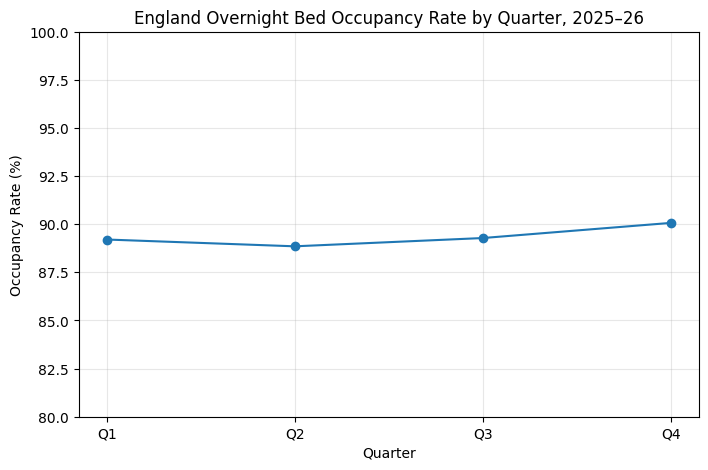

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    national_trend["quarter"],
    national_trend["occupancy_total"],
    marker="o"
)

plt.title("England Overnight Bed Occupancy Rate by Quarter, 2025–26")
plt.xlabel("Quarter")
plt.ylabel("Occupancy Rate (%)")
plt.ylim(80, 100)
plt.grid(True, alpha=0.3)

plt.show()

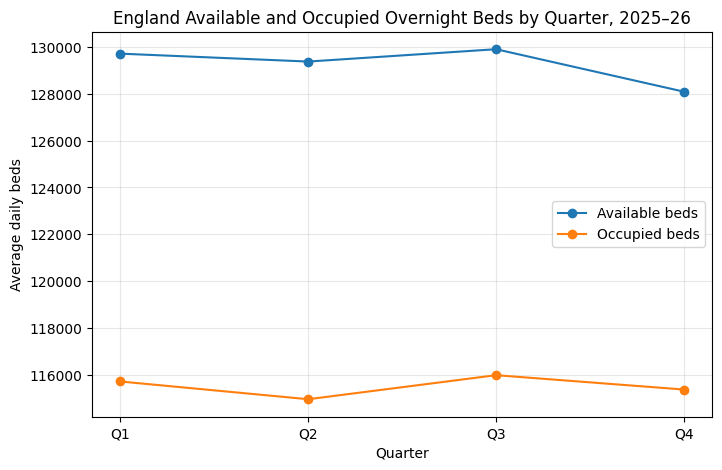

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    national_trend["quarter"],
    national_trend["available_total"],
    marker="o",
    label="Available beds"
)

plt.plot(
    national_trend["quarter"],
    national_trend["occupied_total"],
    marker="o",
    label="Occupied beds"
)

plt.title("England Available and Occupied Overnight Beds by Quarter, 2025–26")
plt.xlabel("Quarter")
plt.ylabel("Average daily beds")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

### National Findings

At national level, overnight bed occupancy remained consistently high throughout 2025–26, ranging from 88.9% in Q2 to 90.1% in Q4. Occupancy dipped slightly in Q2 before increasing in Q3 and reaching its highest point in Q4.

Although occupied beds decreased slightly between Q3 and Q4, available beds decreased more sharply, leading to an increase in the overall occupancy rate. This suggests that hospital capacity pressure may be influenced not only by occupied bed numbers, but also by changes in available bed capacity.

The General & Acute occupancy rate followed a similar pattern and reached 92.5% in Q4, indicating particularly high pressure in the bed sector most closely linked to urgent and emergency care patient flow.

## Regional Bed Occupancy Analysis

National averages can hide important regional variation. This section compares overnight bed availability, occupied beds and occupancy rates across NHS regions to identify areas with higher capacity pressure during 2025–26.

In [18]:
def clean_region_by_sector(file_path, quarter):
    """
    Cleans the Region by Sector sheet from the NHS England
    Bed Availability and Occupancy overnight Excel files.
    """

    df = pd.read_excel(
        file_path,
        sheet_name="Region by Sector",
        header=14
    )

    # Remove completely empty rows
    df = df.dropna(how="all")

    # Select useful columns from the original Excel layout
    # 1-9: Year, Period End, Region Code, AT Name, Available beds
    # 11-15: Occupied beds
    # 17-21: Occupancy rates
    keep_positions = list(range(1, 10)) + list(range(11, 16)) + list(range(17, 22))
    df = df.iloc[:, keep_positions]

    df.columns = [
        "year",
        "period_end",
        "region_code",
        "region_name",
        "available_total",
        "available_general_acute",
        "available_learning_disabilities",
        "available_maternity",
        "available_mental_illness",
        "occupied_total",
        "occupied_general_acute",
        "occupied_learning_disabilities",
        "occupied_maternity",
        "occupied_mental_illness",
        "occupancy_total",
        "occupancy_general_acute",
        "occupancy_learning_disabilities",
        "occupancy_maternity",
        "occupancy_mental_illness"
    ]

    df["quarter"] = quarter

    # Remove blank rows and repeated header rows
    df = df[df["region_name"].notna()]
    df = df[df["year"].notna()]
    df = df[df["year"].astype(str).str.strip() != "Year"]
    df = df[df["region_name"].astype(str).str.strip() != "AT Name"]

    # Replace '-' with missing values
    df = df.replace("-", np.nan)

    numeric_cols = [
        "available_total",
        "available_general_acute",
        "available_learning_disabilities",
        "available_maternity",
        "available_mental_illness",
        "occupied_total",
        "occupied_general_acute",
        "occupied_learning_disabilities",
        "occupied_maternity",
        "occupied_mental_illness",
        "occupancy_total",
        "occupancy_general_acute",
        "occupancy_learning_disabilities",
        "occupancy_maternity",
        "occupancy_mental_illness"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Convert occupancy rates from decimal to percentage
    occupancy_cols = [
        "occupancy_total",
        "occupancy_general_acute",
        "occupancy_learning_disabilities",
        "occupancy_maternity",
        "occupancy_mental_illness"
    ]

    for col in occupancy_cols:
        df[col] = df[col] * 100

    column_order = [
        "year",
        "quarter",
        "period_end",
        "region_code",
        "region_name",
        "available_total",
        "occupied_total",
        "occupancy_total",
        "available_general_acute",
        "occupied_general_acute",
        "occupancy_general_acute",
        "available_learning_disabilities",
        "occupied_learning_disabilities",
        "occupancy_learning_disabilities",
        "available_maternity",
        "occupied_maternity",
        "occupancy_maternity",
        "available_mental_illness",
        "occupied_mental_illness",
        "occupancy_mental_illness"
    ]

    df = df[column_order]

    return df

In [19]:
region_clean_list = []

for quarter, file_name in bed_files.items():
    file_path = os.path.join(data_path, file_name)
    temp_df = clean_region_by_sector(file_path, quarter)
    region_clean_list.append(temp_df)

region_by_sector = pd.concat(region_clean_list, ignore_index=True)

region_by_sector.head()

,year,quarter,period_end,region_code,region_name,available_total,occupied_total,occupancy_total,available_general_acute,occupied_general_acute,occupancy_general_acute,available_learning_disabilities,occupied_learning_disabilities,occupancy_learning_disabilities,available_maternity,occupied_maternity,occupancy_maternity,available_mental_illness,occupied_mental_illness,occupancy_mental_illness
0,2025-26,Q1,June,NaN,England,129716.450549,115713.142857,89.204679,104259.824176,95349.637363,91.453864,717.989011,432.362637,60.218559,7364.780220,4494.934066,61.032834,17373.857143,15436.208791,88.847333
1,2025-26,Q1,June,Y56,LONDON,20207.186813,17973.296703,88.945071,15855.923077,14354.659341,90.531843,23.109890,15.109890,65.382786,1277.032967,820.637363,64.261251,3051.120879,2782.890110,91.208779
2,2025-26,Q1,June,Y58,SOUTH WEST,12184.296703,11106.120879,91.151103,10196.197802,9554.032967,93.701919,17.000000,10.142857,59.663866,623.912088,348.560440,55.866916,1347.186813,1193.384615,88.583454
3,2025-26,Q1,June,Y59,SOUTH EAST,17636.406593,15833.076923,89.774960,14347.153846,13202.714286,92.023229,47.131868,34.120879,72.394498,1049.241758,620.109890,59.100764,2192.879121,1976.131868,90.115860
4,2025-26,Q1,June,Y60,MIDLANDS,24775.714286,22144.373626,89.379355,19941.087912,18224.637363,91.392393,190.472527,122.879121,64.512779,1480.252747,996.285714,67.305108,3163.901099,2800.571429,88.516402


In [20]:
quarter_order = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}

region_by_sector["quarter_order"] = region_by_sector["quarter"].map(quarter_order)

region_by_sector = region_by_sector.sort_values(
    ["quarter_order", "region_name"]
)

region_by_sector.head()

,year,quarter,period_end,region_code,region_name,available_total,occupied_total,occupancy_total,available_general_acute,occupied_general_acute,occupancy_general_acute,available_learning_disabilities,occupied_learning_disabilities,occupancy_learning_disabilities,available_maternity,occupied_maternity,occupancy_maternity,available_mental_illness,occupied_mental_illness,occupancy_mental_illness,quarter_order
5,2025-26,Q1,June,Y61,EAST OF ENGLAND,13486.769231,11942.483516,88.549625,11057.329670,10036.747253,90.770082,60.000000,34.296703,57.161172,822.890110,506.406593,61.540002,1546.549451,1365.032967,88.263131,1
0,2025-26,Q1,June,NaN,England,129716.450549,115713.142857,89.204679,104259.824176,95349.637363,91.453864,717.989011,432.362637,60.218559,7364.780220,4494.934066,61.032834,17373.857143,15436.208791,88.847333,1
1,2025-26,Q1,June,Y56,LONDON,20207.186813,17973.296703,88.945071,15855.923077,14354.659341,90.531843,23.109890,15.109890,65.382786,1277.032967,820.637363,64.261251,3051.120879,2782.890110,91.208779,1
4,2025-26,Q1,June,Y60,MIDLANDS,24775.714286,22144.373626,89.379355,19941.087912,18224.637363,91.392393,190.472527,122.879121,64.512779,1480.252747,996.285714,67.305108,3163.901099,2800.571429,88.516402,1
7,2025-26,Q1,June,Y63,NORTH EAST AND YORKSHIRE,21941.769231,19262.527473,87.789308,17637.868132,15909.659341,90.201714,241.000000,154.890110,64.269755,1153.241758,630.285714,54.653390,2909.659341,2567.692308,88.247180,1


In [21]:
region_only = region_by_sector[region_by_sector["region_name"] != "England"].copy()

region_only.shape

(28, 21)

In [22]:
regional_average = (
    region_only
    .groupby("region_name", as_index=False)
    .agg(
        avg_occupancy_total=("occupancy_total", "mean"),
        avg_occupancy_general_acute=("occupancy_general_acute", "mean"),
        avg_available_total=("available_total", "mean"),
        avg_occupied_total=("occupied_total", "mean")
    )
    .sort_values("avg_occupancy_total", ascending=False)
)

regional_average

,region_name,avg_occupancy_total,avg_occupancy_general_acute,avg_available_total,avg_occupied_total
6,SOUTH WEST,91.421097,93.687050,12109.597123,11070.877200
2,MIDLANDS,89.613936,91.859367,24294.838596,21770.763093
4,NORTH WEST,89.596924,92.139542,19183.441718,17185.210137
5,SOUTH EAST,89.430816,91.611501,17585.115296,15726.495137
1,LONDON,89.244105,90.915101,20625.343986,18407.380818
0,EAST OF ENGLAND,89.158054,91.459893,13442.662598,11982.781990
3,NORTH EAST AND YORKSHIRE,87.875619,90.277142,22031.812899,19361.563269


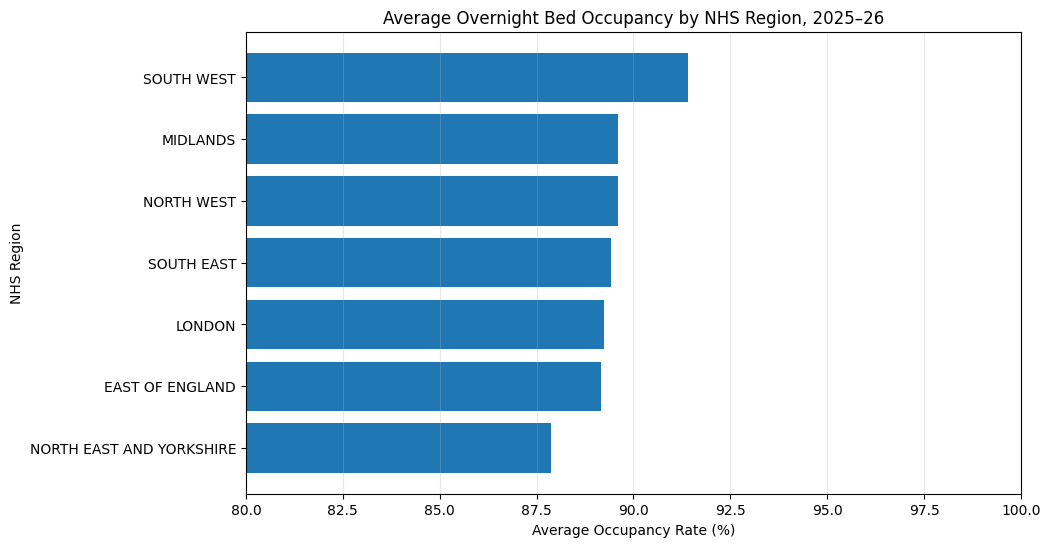

In [23]:
plt.figure(figsize=(10, 6))

plt.barh(
    regional_average["region_name"],
    regional_average["avg_occupancy_total"]
)

plt.title("Average Overnight Bed Occupancy by NHS Region, 2025–26")
plt.xlabel("Average Occupancy Rate (%)")
plt.ylabel("NHS Region")
plt.xlim(80, 100)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

In [24]:
regional_quarter_pivot = region_only.pivot_table(
    index="region_name",
    columns="quarter",
    values="occupancy_total"
)

regional_quarter_pivot

quarter,Q1,Q2,Q3,Q4
region_name,,,,
EAST OF ENGLAND,88.549625,88.512321,89.283040,90.287229
LONDON,88.945071,88.590377,89.488540,89.952432
MIDLANDS,89.379355,89.316971,89.531878,90.227540
NORTH EAST AND YORKSHIRE,87.789308,86.883501,88.064808,88.764861
NORTH WEST,89.565737,89.091124,88.846405,90.884430
SOUTH EAST,89.774960,89.500325,89.129052,89.318926
SOUTH WEST,91.151103,90.997851,91.578278,91.957154


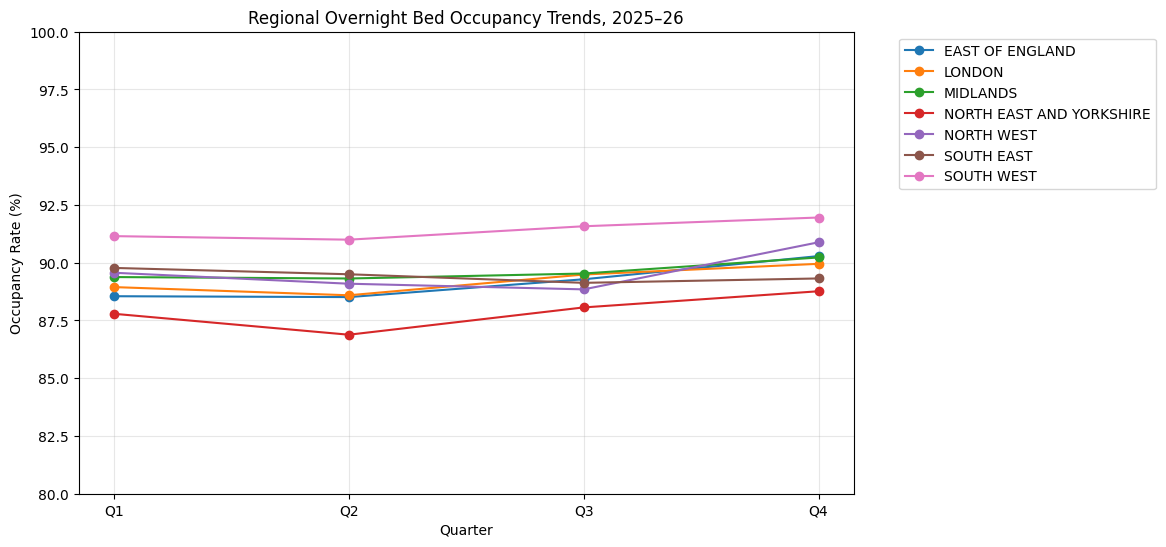

In [25]:
plt.figure(figsize=(10, 6))

for region in region_only["region_name"].unique():
    temp = region_only[region_only["region_name"] == region].sort_values("quarter_order")
    plt.plot(
        temp["quarter"],
        temp["occupancy_total"],
        marker="o",
        label=region
    )

plt.title("Regional Overnight Bed Occupancy Trends, 2025–26")
plt.xlabel("Quarter")
plt.ylabel("Occupancy Rate (%)")
plt.ylim(80, 100)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### Regional Findings

Regional analysis showed that overnight bed occupancy varied across NHS regions during 2025–26. The South West had the highest average total overnight occupancy at 91.4%, followed by the Midlands and North West at around 89.6%.

The South West also had the highest average General & Acute occupancy at 93.7%, indicating particularly high pressure in the bed sector most closely linked to urgent and emergency care patient flow. Although North East and Yorkshire had the lowest average total occupancy at 87.9%, its General & Acute occupancy still averaged above 90%.

These findings show that national averages can hide important regional variation. Some regions appear to have had less spare capacity than others, which may affect their ability to absorb emergency demand, delayed discharges or seasonal pressures.

## Provider-Level High Occupancy Analysis

This section examines provider-level variation in overnight bed occupancy across NHS trusts during 2025–26.

The England national summary row is excluded so that provider comparisons are not distorted. The analysis focuses on identifying trusts with the highest average occupancy, trusts exceeding high occupancy thresholds, and providers with consistently high occupancy across multiple quarters.

In [26]:
provider_average = (
    trust_provider
    .groupby(["org_code", "org_name", "region_code"], as_index=False)
    .agg(
        avg_occupancy_total=("occupancy_total", "mean"),
        avg_occupancy_general_acute=("occupancy_general_acute", "mean"),
        avg_available_total=("available_total", "mean"),
        avg_occupied_total=("occupied_total", "mean"),
        quarters_reported=("quarter", "nunique")
    )
    .sort_values("avg_occupancy_total", ascending=False)
)

provider_average.head(20)

,org_code,org_name,region_code,avg_occupancy_total,avg_occupancy_general_acute,avg_available_total,avg_occupied_total,quarters_reported
88,RLT,GEORGE ELIOT HOSPITAL NHS TRUST,Y60,98.860017,98.792621,410.404808,405.702817,4
153,RW5,LANCASHIRE CARE NHS FOUNDATION TRUST,Y62,97.821170,NaN,589.511111,576.666667,1
128,RRK,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,Y60,97.292742,97.339648,2860.610189,2783.003442,4
37,RCX,"THE QUEEN ELIZABETH HOSPITAL, KING'S LYNN, NHS...",Y61,96.604085,97.453864,508.828211,491.448027,4
66,RHW,ROYAL BERKSHIRE NHS FOUNDATION TRUST,Y59,96.338957,96.791408,658.722380,634.756938,4
44,REM,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,Y62,96.025674,96.025674,1536.284110,1475.142763,4
25,RBN,MERSEY AND WEST LANCASHIRE TEACHING HOSPITALS ...,Y62,95.756429,97.850502,1259.087992,1205.649944,3
168,RWV,DEVON PARTNERSHIP NHS TRUST,Y58,95.398366,NaN,264.298678,252.086344,4
144,RVJ,NORTH BRISTOL NHS TRUST,Y58,95.349942,96.668646,1028.722213,980.896114,4
31,RC9,BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,Y61,95.322009,95.039340,1123.663346,1071.206950,4


In [27]:
provider_average_full_year = provider_average[
    provider_average["quarters_reported"] == 4
].copy()

provider_average_full_year.head(20)

,org_code,org_name,region_code,avg_occupancy_total,avg_occupancy_general_acute,avg_available_total,avg_occupied_total,quarters_reported
88,RLT,GEORGE ELIOT HOSPITAL NHS TRUST,Y60,98.860017,98.792621,410.404808,405.702817,4
128,RRK,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,Y60,97.292742,97.339648,2860.610189,2783.003442,4
37,RCX,"THE QUEEN ELIZABETH HOSPITAL, KING'S LYNN, NHS...",Y61,96.604085,97.453864,508.828211,491.448027,4
66,RHW,ROYAL BERKSHIRE NHS FOUNDATION TRUST,Y59,96.338957,96.791408,658.722380,634.756938,4
44,REM,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,Y62,96.025674,96.025674,1536.284110,1475.142763,4
168,RWV,DEVON PARTNERSHIP NHS TRUST,Y58,95.398366,NaN,264.298678,252.086344,4
144,RVJ,NORTH BRISTOL NHS TRUST,Y58,95.349942,96.668646,1028.722213,980.896114,4
31,RC9,BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,Y61,95.322009,95.039340,1123.663346,1071.206950,4
95,RN3,GREAT WESTERN HOSPITALS NHS FOUNDATION TRUST,Y58,95.316827,95.949525,594.468643,566.676929,4
189,RXQ,BUCKINGHAMSHIRE HEALTHCARE NHS TRUST,Y59,95.289435,99.435887,552.750000,526.727838,4


In [28]:
top15_provider_occupancy = provider_average_full_year.head(15)

top15_provider_occupancy

,org_code,org_name,region_code,avg_occupancy_total,avg_occupancy_general_acute,avg_available_total,avg_occupied_total,quarters_reported
88,RLT,GEORGE ELIOT HOSPITAL NHS TRUST,Y60,98.860017,98.792621,410.404808,405.702817,4
128,RRK,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,Y60,97.292742,97.339648,2860.610189,2783.003442,4
37,RCX,"THE QUEEN ELIZABETH HOSPITAL, KING'S LYNN, NHS...",Y61,96.604085,97.453864,508.828211,491.448027,4
66,RHW,ROYAL BERKSHIRE NHS FOUNDATION TRUST,Y59,96.338957,96.791408,658.722380,634.756938,4
44,REM,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,Y62,96.025674,96.025674,1536.284110,1475.142763,4
168,RWV,DEVON PARTNERSHIP NHS TRUST,Y58,95.398366,NaN,264.298678,252.086344,4
144,RVJ,NORTH BRISTOL NHS TRUST,Y58,95.349942,96.668646,1028.722213,980.896114,4
31,RC9,BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,Y61,95.322009,95.039340,1123.663346,1071.206950,4
95,RN3,GREAT WESTERN HOSPITALS NHS FOUNDATION TRUST,Y58,95.316827,95.949525,594.468643,566.676929,4
189,RXQ,BUCKINGHAMSHIRE HEALTHCARE NHS TRUST,Y59,95.289435,99.435887,552.750000,526.727838,4


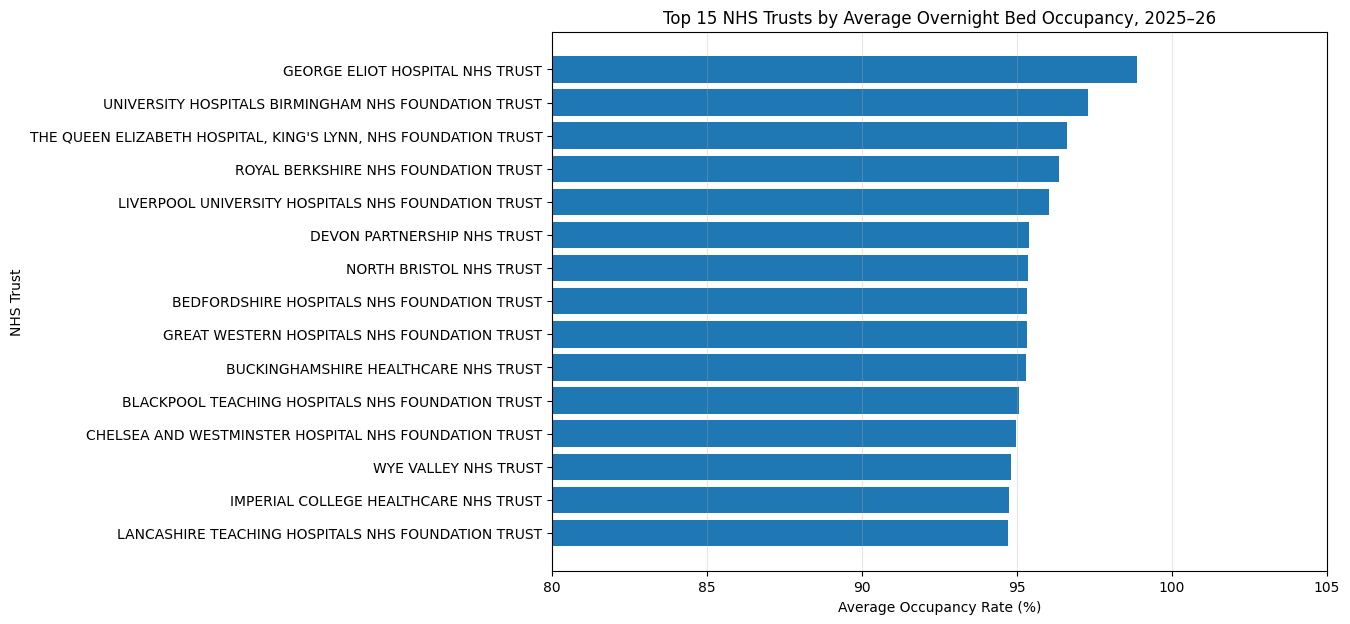

In [29]:
plt.figure(figsize=(10, 7))

plt.barh(
    top15_provider_occupancy["org_name"],
    top15_provider_occupancy["avg_occupancy_total"]
)

plt.title("Top 15 NHS Trusts by Average Overnight Bed Occupancy, 2025–26")
plt.xlabel("Average Occupancy Rate (%)")
plt.ylabel("NHS Trust")
plt.xlim(80, 105)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

In [30]:
high_occupancy_summary = (
    trust_provider
    .groupby("quarter", as_index=False)
    .agg(
        providers_reported=("org_name", "nunique"),
        providers_above_92=("high_occupancy_92", "sum"),
        providers_above_95=("high_occupancy_95", "sum")
    )
)

high_occupancy_summary["pct_providers_above_92"] = (
    high_occupancy_summary["providers_above_92"] /
    high_occupancy_summary["providers_reported"] * 100
)

high_occupancy_summary["pct_providers_above_95"] = (
    high_occupancy_summary["providers_above_95"] /
    high_occupancy_summary["providers_reported"] * 100
)

high_occupancy_summary

,quarter,providers_reported,providers_above_92,providers_above_95,pct_providers_above_92,pct_providers_above_95
0,Q1,183,53,15,28.961749,8.196721
1,Q2,184,50,9,27.173913,4.891304
2,Q3,184,48,15,26.086957,8.152174
3,Q4,184,59,27,32.065217,14.673913


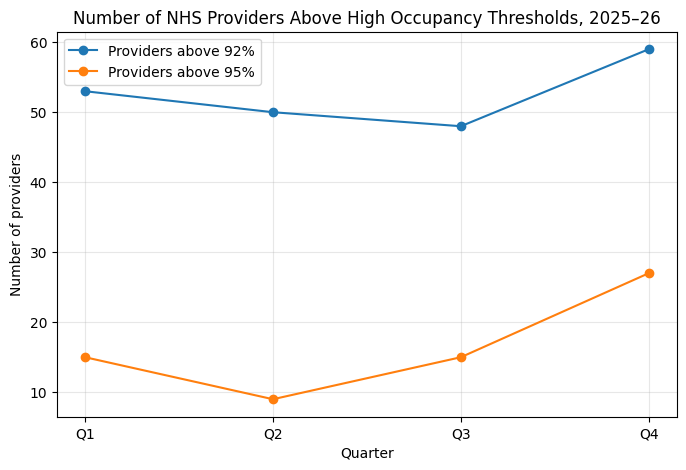

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    high_occupancy_summary["quarter"],
    high_occupancy_summary["providers_above_92"],
    marker="o",
    label="Providers above 92%"
)

plt.plot(
    high_occupancy_summary["quarter"],
    high_occupancy_summary["providers_above_95"],
    marker="o",
    label="Providers above 95%"
)

plt.title("Number of NHS Providers Above High Occupancy Thresholds, 2025–26")
plt.xlabel("Quarter")
plt.ylabel("Number of providers")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [32]:
consistent_high_occupancy = (
    trust_provider
    .groupby(["org_code", "org_name", "region_code"], as_index=False)
    .agg(
        quarters_reported=("quarter", "nunique"),
        quarters_above_92=("high_occupancy_92", "sum"),
        quarters_above_95=("high_occupancy_95", "sum"),
        avg_occupancy_total=("occupancy_total", "mean"),
        max_occupancy_total=("occupancy_total", "max")
    )
    .sort_values(
        ["quarters_above_92", "avg_occupancy_total"],
        ascending=[False, False]
    )
)

consistent_high_occupancy.head(20)

,org_code,org_name,region_code,quarters_reported,quarters_above_92,quarters_above_95,avg_occupancy_total,max_occupancy_total
88,RLT,GEORGE ELIOT HOSPITAL NHS TRUST,Y60,4,4,4,98.860017,99.322114
128,RRK,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,Y60,4,4,4,97.292742,98.062923
37,RCX,"THE QUEEN ELIZABETH HOSPITAL, KING'S LYNN, NHS...",Y61,4,4,3,96.604085,98.367962
66,RHW,ROYAL BERKSHIRE NHS FOUNDATION TRUST,Y59,4,4,2,96.338957,99.270426
44,REM,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,Y62,4,4,4,96.025674,96.907514
168,RWV,DEVON PARTNERSHIP NHS TRUST,Y58,4,4,3,95.398366,97.270729
144,RVJ,NORTH BRISTOL NHS TRUST,Y58,4,4,3,95.349942,96.037274
31,RC9,BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,Y61,4,4,2,95.322009,96.976001
95,RN3,GREAT WESTERN HOSPITALS NHS FOUNDATION TRUST,Y58,4,4,2,95.316827,95.860586
189,RXQ,BUCKINGHAMSHIRE HEALTHCARE NHS TRUST,Y59,4,4,2,95.289435,95.982863


In [33]:
providers_above_92_all_year = consistent_high_occupancy[
    (consistent_high_occupancy["quarters_reported"] == 4) &
    (consistent_high_occupancy["quarters_above_92"] == 4)
].copy()

providers_above_92_all_year.sort_values("avg_occupancy_total", ascending=False)

,org_code,org_name,region_code,quarters_reported,quarters_above_92,quarters_above_95,avg_occupancy_total,max_occupancy_total
88,RLT,GEORGE ELIOT HOSPITAL NHS TRUST,Y60,4,4,4,98.860017,99.322114
128,RRK,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,Y60,4,4,4,97.292742,98.062923
37,RCX,"THE QUEEN ELIZABETH HOSPITAL, KING'S LYNN, NHS...",Y61,4,4,3,96.604085,98.367962
66,RHW,ROYAL BERKSHIRE NHS FOUNDATION TRUST,Y59,4,4,2,96.338957,99.270426
44,REM,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,Y62,4,4,4,96.025674,96.907514
168,RWV,DEVON PARTNERSHIP NHS TRUST,Y58,4,4,3,95.398366,97.270729
144,RVJ,NORTH BRISTOL NHS TRUST,Y58,4,4,3,95.349942,96.037274
31,RC9,BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,Y61,4,4,2,95.322009,96.976001
95,RN3,GREAT WESTERN HOSPITALS NHS FOUNDATION TRUST,Y58,4,4,2,95.316827,95.860586
189,RXQ,BUCKINGHAMSHIRE HEALTHCARE NHS TRUST,Y59,4,4,2,95.289435,95.982863


In [34]:
provider_quarter_occupancy = trust_provider.pivot_table(
    index="org_name",
    columns="quarter",
    values="occupancy_total"
)

provider_quarter_occupancy.head()

quarter,Q1,Q2,Q3,Q4
org_name,,,,
AIREDALE NHS FOUNDATION TRUST,89.260143,87.726152,88.315772,91.088544
ALDER HEY CHILDREN'S NHS FOUNDATION TRUST,69.896301,71.713615,68.360890,72.493479
ASHFORD AND ST PETER'S HOSPITALS NHS FOUNDATION TRUST,88.721271,86.853942,88.344775,90.168599
AVON AND WILTSHIRE MENTAL HEALTH PARTNERSHIP NHS TRUST,86.816640,89.601054,88.644566,90.776412
"BARKING, HAVERING AND REDBRIDGE UNIVERSITY HOSPITALS NHS TRUST",88.232298,86.960635,88.690955,97.133960


In [35]:
top20_provider_names = provider_average_full_year.head(20)["org_name"].tolist()

top20_heatmap_data = provider_quarter_occupancy.loc[top20_provider_names]

top20_heatmap_data

quarter,Q1,Q2,Q3,Q4
org_name,,,,
GEORGE ELIOT HOSPITAL NHS TRUST,98.517720,99.155907,99.322114,98.444329
UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST,97.825530,98.062923,96.586972,96.695542
"THE QUEEN ELIZABETH HOSPITAL, KING'S LYNN, NHS FOUNDATION TRUST",95.211707,94.702401,98.134271,98.367962
ROYAL BERKSHIRE NHS FOUNDATION TRUST,97.976737,93.559552,94.549113,99.270426
LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION TRUST,95.709134,96.907514,95.151274,96.334775
DEVON PARTNERSHIP NHS TRUST,92.773931,97.270729,95.702147,95.846659
NORTH BRISTOL NHS TRUST,95.325146,94.745511,96.037274,95.291837
BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,93.966292,94.876303,95.469439,96.976001
GREAT WESTERN HOSPITALS NHS FOUNDATION TRUST,94.685219,94.960992,95.760512,95.860586


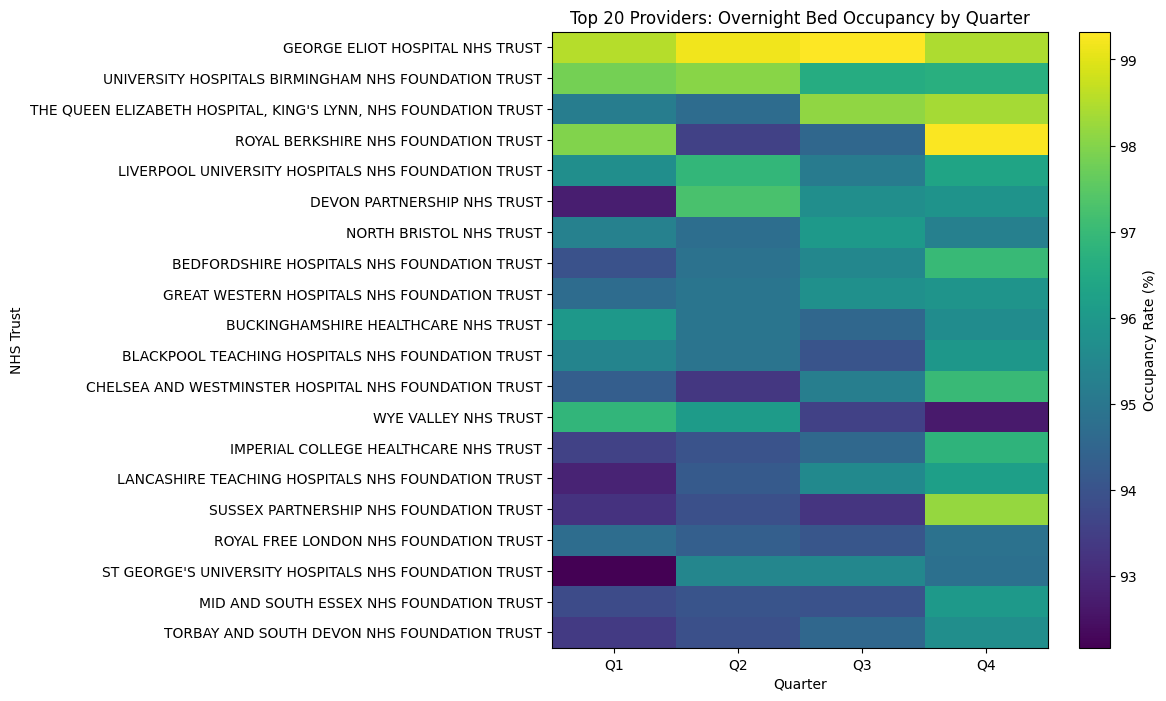

In [36]:
plt.figure(figsize=(8, 8))

plt.imshow(top20_heatmap_data, aspect="auto")

plt.xticks(
    ticks=range(len(top20_heatmap_data.columns)),
    labels=top20_heatmap_data.columns
)

plt.yticks(
    ticks=range(len(top20_heatmap_data.index)),
    labels=top20_heatmap_data.index
)

plt.title("Top 20 Providers: Overnight Bed Occupancy by Quarter")
plt.xlabel("Quarter")
plt.ylabel("NHS Trust")

plt.colorbar(label="Occupancy Rate (%)")

plt.show()

### Provider-Level Findings

Provider-level analysis showed substantial variation in overnight bed occupancy across NHS trusts during 2025–26.

The number of providers above the 92% occupancy threshold remained high throughout the year, ranging from 48 providers in Q3 to 59 providers in Q4. The number of providers above 95% occupancy increased notably in Q4, rising to 27 providers compared with 15 in Q3 and 9 in Q2.

This suggests that provider-level capacity pressure intensified toward the end of the financial year, even though national-level occupancy changes appeared relatively modest.

Several trusts showed consistently high occupancy across the full year. George Eliot Hospital NHS Trust had the highest average total overnight occupancy at 98.9%, followed by University Hospitals Birmingham NHS Foundation Trust at 97.3% and The Queen Elizabeth Hospital, King’s Lynn NHS Foundation Trust at 96.6%.

In total, 28 providers were above 92% occupancy in all four quarters of 2025–26. This indicates that some NHS organisations had persistently limited spare bed capacity, which may reduce flexibility to manage emergency demand, delayed discharges or seasonal increases in pressure.

## Sector-Level Bed Occupancy Analysis

This section compares overnight bed occupancy across different NHS bed sectors during 2025–26.

The overall total occupancy measure was used in the national and provider-level analysis. For the sector-level comparison, the total column is excluded because it represents an aggregate across bed sectors rather than a distinct bed sector.

The analysis focuses on:

- General & Acute
- Mental Illness
- Maternity
- Learning Disabilities

General & Acute beds are particularly important because they are most closely linked to urgent and emergency care admissions and wider hospital patient flow.

In [37]:
sector_frames = []

sector_mapping = {
    "General & Acute": {
        "available": "available_general_acute",
        "occupied": "occupied_general_acute",
        "occupancy": "occupancy_general_acute"
    },
    "Learning Disabilities": {
        "available": "available_learning_disabilities",
        "occupied": "occupied_learning_disabilities",
        "occupancy": "occupancy_learning_disabilities"
    },
    "Maternity": {
        "available": "available_maternity",
        "occupied": "occupied_maternity",
        "occupancy": "occupancy_maternity"
    },
    "Mental Illness": {
        "available": "available_mental_illness",
        "occupied": "occupied_mental_illness",
        "occupancy": "occupancy_mental_illness"
    }
}

for sector, cols in sector_mapping.items():
    temp = trust_provider[
        [
            "year",
            "quarter",
            "period_end",
            "region_code",
            "org_code",
            "org_name"
        ]
    ].copy()
    
    temp["sector"] = sector
    temp["available_beds"] = trust_provider[cols["available"]]
    temp["occupied_beds"] = trust_provider[cols["occupied"]]
    temp["occupancy_rate"] = trust_provider[cols["occupancy"]]
    
    sector_frames.append(temp)

sector_provider_long = pd.concat(sector_frames, ignore_index=True)

sector_provider_long = sector_provider_long[
    sector_provider_long["available_beds"].notna() &
    (sector_provider_long["available_beds"] > 0)
].copy()

sector_provider_long.head()

,year,quarter,period_end,region_code,org_code,org_name,sector,available_beds,occupied_beds,occupancy_rate
0,2025-26,Q1,June,Y56,R1H,BARTS HEALTH NHS TRUST,General & Acute,1969.538462,1859.978022,94.437253
1,2025-26,Q1,June,Y56,R1K,LONDON NORTH WEST UNIVERSITY HEALTHCARE NHS TRUST,General & Acute,1036.527473,948.428571,91.500572
2,2025-26,Q1,June,Y56,RAL,ROYAL FREE LONDON NHS FOUNDATION TRUST,General & Acute,1448.824176,1420.703297,98.059055
3,2025-26,Q1,June,Y56,RAN,ROYAL NATIONAL ORTHOPAEDIC HOSPITAL NHS TRUST,General & Acute,142.846154,110.098901,77.075160
4,2025-26,Q1,June,Y56,RAS,THE HILLINGDON HOSPITALS NHS FOUNDATION TRUST,General & Acute,388.670330,366.945055,94.410359


In [38]:
sector_average = (
    sector_provider_long
    .groupby("sector", as_index=False)
    .agg(
        avg_occupancy_rate=("occupancy_rate", "mean"),
        avg_available_beds=("available_beds", "mean"),
        avg_occupied_beds=("occupied_beds", "mean"),
        provider_quarter_records=("org_name", "count")
    )
    .sort_values("avg_occupancy_rate", ascending=False)
)

sector_average

,sector,avg_occupancy_rate,avg_available_beds,avg_occupied_beds,provider_quarter_records
0,General & Acute,88.926483,678.076480,621.001790,610
3,Mental Illness,84.455434,319.100999,284.209189,224
2,Maternity,61.220133,63.061338,38.519546,462
1,Learning Disabilities,59.310966,23.567225,14.465340,121


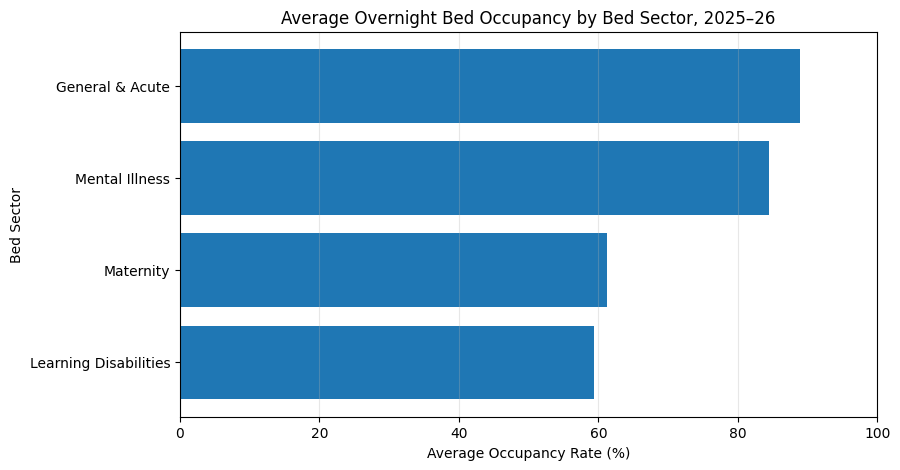

In [39]:
plt.figure(figsize=(9, 5))

plt.barh(
    sector_average["sector"],
    sector_average["avg_occupancy_rate"]
)

plt.title("Average Overnight Bed Occupancy by Bed Sector, 2025–26")
plt.xlabel("Average Occupancy Rate (%)")
plt.ylabel("Bed Sector")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

In [40]:
sector_quarter_average = (
    sector_provider_long
    .groupby(["quarter", "sector"], as_index=False)
    .agg(
        avg_occupancy_rate=("occupancy_rate", "mean"),
        avg_available_beds=("available_beds", "mean"),
        avg_occupied_beds=("occupied_beds", "mean")
    )
)

sector_quarter_average["quarter_order"] = sector_quarter_average["quarter"].map(quarter_order)

sector_quarter_average = sector_quarter_average.sort_values(
    ["sector", "quarter_order"]
)

sector_quarter_average

,quarter,sector,avg_occupancy_rate,avg_available_beds,avg_occupied_beds,quarter_order
0,Q1,General & Acute,88.761938,681.436759,623.200244,1
4,Q2,General & Acute,88.269418,669.610248,608.802583,2
8,Q3,General & Acute,89.004987,674.183371,616.681536,3
12,Q4,General & Acute,89.693420,687.400075,635.818121,4
1,Q1,Learning Disabilities,61.872293,23.932967,14.412088,1
5,Q2,Learning Disabilities,58.383556,24.506522,14.422826,2
9,Q3,Learning Disabilities,56.448963,23.734572,14.592216,3
13,Q4,Learning Disabilities,60.634451,22.089259,14.430000,4
2,Q1,Maternity,60.832515,62.946839,38.418240,1
6,Q2,Maternity,62.119065,62.697789,39.008547,2


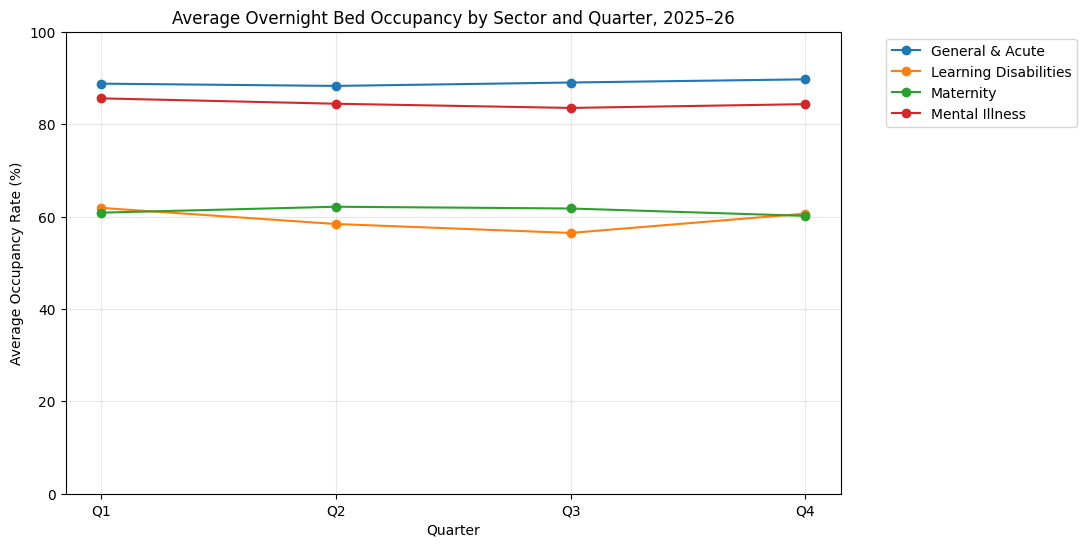

In [41]:
plt.figure(figsize=(10, 6))

for sector in sector_quarter_average["sector"].unique():
    temp = sector_quarter_average[
        sector_quarter_average["sector"] == sector
    ].sort_values("quarter_order")
    
    plt.plot(
        temp["quarter"],
        temp["avg_occupancy_rate"],
        marker="o",
        label=sector
    )

plt.title("Average Overnight Bed Occupancy by Sector and Quarter, 2025–26")
plt.xlabel("Quarter")
plt.ylabel("Average Occupancy Rate (%)")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

In [42]:
general_acute = sector_provider_long[
    sector_provider_long["sector"] == "General & Acute"
].copy()

general_acute_summary = (
    general_acute
    .groupby("quarter", as_index=False)
    .agg(
        providers_reported=("org_name", "nunique"),
        avg_occupancy_rate=("occupancy_rate", "mean"),
        providers_above_92=("occupancy_rate", lambda x: (x >= 92).sum()),
        providers_above_95=("occupancy_rate", lambda x: (x >= 95).sum())
    )
)

general_acute_summary["pct_providers_above_92"] = (
    general_acute_summary["providers_above_92"] /
    general_acute_summary["providers_reported"] * 100
)

general_acute_summary["pct_providers_above_95"] = (
    general_acute_summary["providers_above_95"] /
    general_acute_summary["providers_reported"] * 100
)

general_acute_summary

,quarter,providers_reported,avg_occupancy_rate,providers_above_92,providers_above_95,pct_providers_above_92,pct_providers_above_95
0,Q1,153,88.761938,65,32,42.483660,20.915033
1,Q2,154,88.269418,61,31,39.610390,20.129870
2,Q3,154,89.004987,70,37,45.454545,24.025974
3,Q4,149,89.693420,82,43,55.033557,28.859060


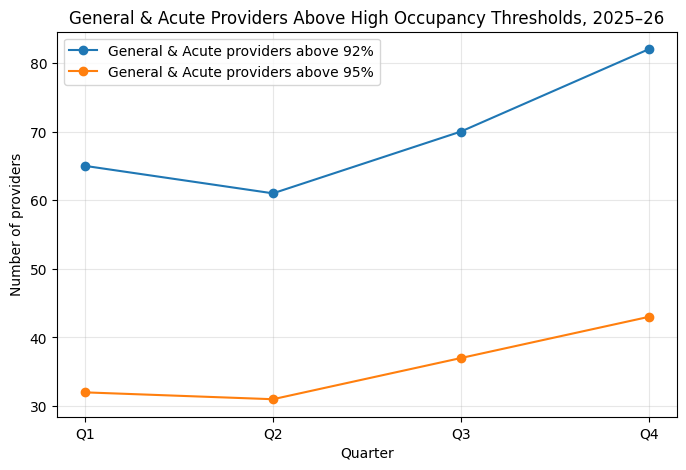

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    general_acute_summary["quarter"],
    general_acute_summary["providers_above_92"],
    marker="o",
    label="General & Acute providers above 92%"
)

plt.plot(
    general_acute_summary["quarter"],
    general_acute_summary["providers_above_95"],
    marker="o",
    label="General & Acute providers above 95%"
)

plt.title("General & Acute Providers Above High Occupancy Thresholds, 2025–26")
plt.xlabel("Quarter")
plt.ylabel("Number of providers")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

### Sector-Level Findings

Sector-level analysis showed clear differences in average overnight bed occupancy across NHS bed sectors during 2025–26.

General & Acute beds had the highest average occupancy at 88.9%, followed by Mental Illness beds at 84.5%. Maternity and Learning Disabilities beds had substantially lower average occupancy, at 61.2% and 59.3% respectively.

This distinction is important because General & Acute beds are most closely linked to urgent and emergency care admissions and wider hospital patient flow. High occupancy in this sector may reduce flexibility for hospitals to admit patients from A&E, manage emergency demand, or respond to seasonal increases in pressure.

The General & Acute high-occupancy analysis showed that the number of providers above 92% occupancy increased from 70 in Q3 to 82 in Q4. Providers above 95% occupancy also increased from 37 in Q3 to 43 in Q4. By Q4, 55.0% of General & Acute providers were above 92% occupancy and 28.9% were above 95%.

These findings suggest that capacity pressure was particularly concentrated in General & Acute beds and became more visible toward the end of the financial year.

## Specialty-Level Occupied Bed Analysis

This section analyses occupied overnight beds by clinical specialty.

Unlike the provider and sector-level analysis, this sheet focuses on occupied beds by specialty rather than available beds or occupancy rates. The aim is to identify which clinical specialties accounted for the largest volume of occupied overnight beds during 2025–26.

The Occupied by Specialty sheet stores each clinical specialty as a separate column. To analyse specialty-level bed use, the dataset is reshaped from wide format into long format, creating one row per provider, quarter and specialty.

In [44]:
def clean_occupied_by_specialty(file_path, quarter):
    """
    Cleans the Occupied by Specialty sheet from the NHS England
    Bed Availability and Occupancy overnight Excel files.

    The raw sheet stores specialties as separate columns, so this function
    converts the data from wide format into long format.
    """

    df = pd.read_excel(
        file_path,
        sheet_name="Occupied by Specialty",
        header=14
    )

    # Remove empty rows and columns
    df = df.dropna(how="all")
    df = df.dropna(axis=1, how="all")

    # Remove first blank Excel column if present
    if str(df.columns[0]).startswith("Unnamed"):
        df = df.iloc[:, 1:]

    # Remove blank spacer rows and repeated header rows
    df = df[df["Org Name"].notna()]
    df = df[df["Year"].notna()]
    df = df[df["Year"].astype(str).str.strip() != "Year"]
    df = df[df["Org Name"].astype(str).str.strip() != "Org Name"]

    # Add quarter label
    df["quarter"] = quarter

    # Identify ID columns and specialty columns
    id_cols = ["Year", "Period End", "Region Code", "Org Code", "Org Name", "quarter"]
    specialty_cols = [col for col in df.columns if col not in id_cols]

    # Convert wide specialty columns into long format
    long_df = df.melt(
        id_vars=id_cols,
        value_vars=specialty_cols,
        var_name="specialty",
        value_name="occupied_beds"
    )

    # Rename ID columns
    long_df = long_df.rename(
        columns={
            "Year": "year",
            "Period End": "period_end",
            "Region Code": "region_code",
            "Org Code": "org_code",
            "Org Name": "org_name"
        }
    )

    # Clean specialty names
    long_df["specialty"] = long_df["specialty"].astype(str).str.strip()

    # Extract specialty code and specialty name
    long_df["specialty_code"] = long_df["specialty"].str.extract(r"^(\d+)")
    long_df["specialty_name"] = long_df["specialty"].str.replace(r"^\d+\s+", "", regex=True)

    # Convert occupied beds to numeric
    long_df["occupied_beds"] = pd.to_numeric(long_df["occupied_beds"], errors="coerce")

    # Remove zero or missing occupied bed rows
    long_df = long_df[
        long_df["occupied_beds"].notna() &
        (long_df["occupied_beds"] > 0)
    ].copy()

    # Reorder columns
    long_df = long_df[
        [
            "year",
            "quarter",
            "period_end",
            "region_code",
            "org_code",
            "org_name",
            "specialty_code",
            "specialty_name",
            "occupied_beds"
        ]
    ]

    return long_df

In [45]:
specialty_clean_list = []

for quarter, file_name in bed_files.items():
    file_path = os.path.join(data_path, file_name)
    temp_df = clean_occupied_by_specialty(file_path, quarter)
    specialty_clean_list.append(temp_df)

occupied_by_specialty = pd.concat(specialty_clean_list, ignore_index=True)

occupied_by_specialty.head()

,year,quarter,period_end,region_code,org_code,org_name,specialty_code,specialty_name,occupied_beds
0,2025-26,Q1,June,NaN,NaN,England,100,General Surgery,9168.648352
1,2025-26,Q1,June,Y56,R1H,BARTS HEALTH NHS TRUST,100,General Surgery,168.395604
2,2025-26,Q1,June,Y56,R1K,LONDON NORTH WEST UNIVERSITY HEALTHCARE NHS TRUST,100,General Surgery,89.527473
3,2025-26,Q1,June,Y56,RAL,ROYAL FREE LONDON NHS FOUNDATION TRUST,100,General Surgery,183.934066
4,2025-26,Q1,June,Y56,RAS,THE HILLINGDON HOSPITALS NHS FOUNDATION TRUST,100,General Surgery,25.384615


In [46]:
occupied_specialty_provider = occupied_by_specialty[
    occupied_by_specialty["org_name"] != "England"
].copy()

occupied_specialty_provider.shape

(13070, 9)

In [47]:
specialty_total = (
    occupied_specialty_provider
    .groupby(["specialty_code", "specialty_name"], as_index=False)
    .agg(
        total_occupied_beds=("occupied_beds", "sum"),
        avg_occupied_beds=("occupied_beds", "mean"),
        provider_quarter_records=("org_name", "count")
    )
    .sort_values("total_occupied_beds", ascending=False)
)

specialty_total.head(20)

,specialty_code,specialty_name,total_occupied_beds,avg_occupied_beds,provider_quarter_records
21,300,General Medicine,82342.653769,175.945841,468
50,430,Geriatric Medicine,65555.760514,134.888396,486
0,100,General Surgery,35577.468400,73.965631,481
57,710,Adult Mental Illness,35076.842440,183.648390,191
3,110,Trauma & Orthopaedics,32350.369045,64.830399,499
38,340,Thoracic Medicine,23242.851609,49.984627,465
33,320,Cardiology,17990.409842,38.523362,467
54,501,Obstetrics,17796.030443,38.855962,458
59,712,Forensic Psychiatry,15010.004292,117.265659,128
22,301,Gastroenterology,14720.146565,31.656229,465


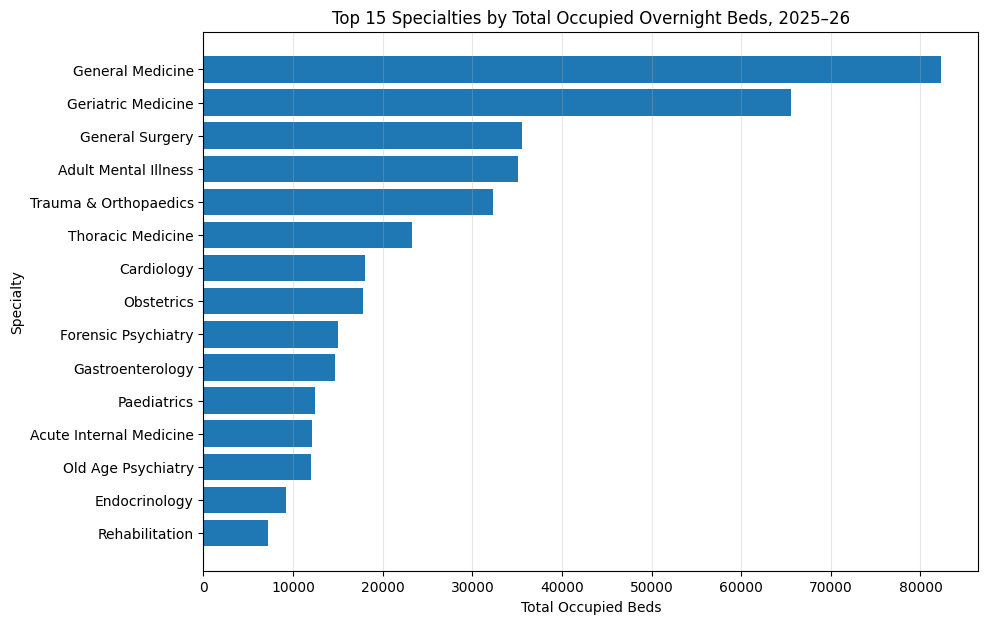

In [48]:
top15_specialties = specialty_total.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top15_specialties["specialty_name"],
    top15_specialties["total_occupied_beds"]
)

plt.title("Top 15 Specialties by Total Occupied Overnight Beds, 2025–26")
plt.xlabel("Total Occupied Beds")
plt.ylabel("Specialty")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

In [49]:
specialty_quarter_total = (
    occupied_specialty_provider
    .groupby(["quarter", "specialty_code", "specialty_name"], as_index=False)
    .agg(
        total_occupied_beds=("occupied_beds", "sum")
    )
)

specialty_quarter_total["quarter_order"] = specialty_quarter_total["quarter"].map(quarter_order)

specialty_quarter_total = specialty_quarter_total.sort_values(
    ["specialty_name", "quarter_order"]
)

specialty_quarter_total.head()

,quarter,specialty_code,specialty_name,total_occupied_beds,quarter_order
16,Q1,180,Accident & Emergency,638.197802,1
86,Q2,180,Accident & Emergency,640.510870,2
157,Q3,180,Accident & Emergency,626.423913,3
230,Q4,180,Accident & Emergency,545.144444,4
34,Q1,326,Acute Internal Medicine,2982.516484,1


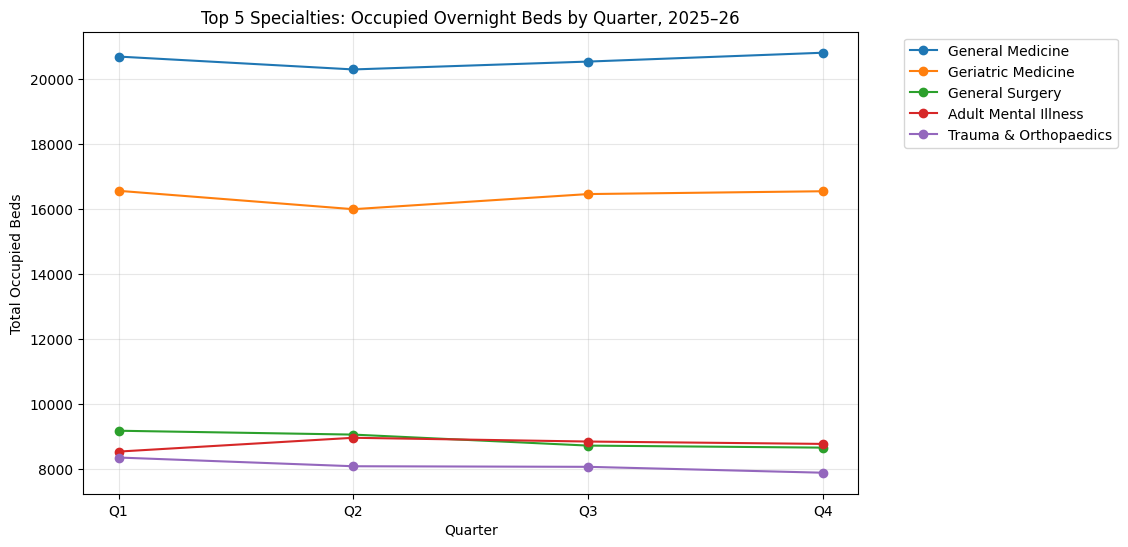

In [50]:
top5_specialties = specialty_total.head(5)["specialty_name"].tolist()

top5_specialty_trends = specialty_quarter_total[
    specialty_quarter_total["specialty_name"].isin(top5_specialties)
].copy()

plt.figure(figsize=(10, 6))

for specialty in top5_specialties:
    temp = top5_specialty_trends[
        top5_specialty_trends["specialty_name"] == specialty
    ].sort_values("quarter_order")
    
    plt.plot(
        temp["quarter"],
        temp["total_occupied_beds"],
        marker="o",
        label=specialty
    )

plt.title("Top 5 Specialties: Occupied Overnight Beds by Quarter, 2025–26")
plt.xlabel("Quarter")
plt.ylabel("Total Occupied Beds")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### Specialty-Level Findings

Specialty-level analysis showed that occupied overnight bed use was concentrated in a small number of clinical specialties during 2025–26.

General Medicine accounted for the highest total occupied overnight bed use, followed by Geriatric Medicine, General Surgery, Adult Mental Illness and Trauma & Orthopaedics. This pattern is clinically meaningful because General Medicine and Geriatric Medicine are closely linked to acute inpatient demand, older adult care, emergency admissions and longer hospital stays.

The prominence of Geriatric Medicine is particularly important in the context of patient flow because older patients may require more complex discharge planning, multidisciplinary input and community care coordination. High occupied bed use in these specialties may therefore contribute to wider hospital capacity pressure, although this analysis cannot prove a direct causal relationship with A&E delays.

Overall, the specialty findings add clinical context to the provider and sector-level results by showing where occupied overnight bed use was most concentrated across NHS organisations.

## Key Findings Summary

The analysis identified several important patterns across NHS overnight bed availability and occupancy during 2025–26:

1. **National occupancy remained high throughout the year.** England-level overnight bed occupancy stayed close to 89–90% across all four quarters and reached its highest point in Q4.

2. **Available bed capacity changed as well as occupied bed use.** Between Q3 and Q4, occupied beds fell slightly, but available beds fell more sharply, causing overall occupancy to increase.

3. **Regional pressure was uneven.** The South West recorded the highest average total occupancy and the highest General & Acute occupancy, showing that national averages can hide regional variation.

4. **Provider-level pressure was concentrated in a subset of trusts.** Twenty-eight providers were above 92% occupancy in all four quarters, suggesting persistently limited spare bed capacity for some organisations.

5. **General & Acute beds showed the clearest link to patient-flow pressure.** This sector had the highest average occupancy and saw a noticeable rise in high-occupancy providers in Q4.

6. **Occupied bed use was concentrated in key specialties.** General Medicine and Geriatric Medicine accounted for the largest occupied overnight bed use, adding clinical context to the operational findings.

## Limitations

Several limitations should be considered when interpreting this analysis.

First, the analysis uses aggregated quarterly data rather than patient-level records. This means the analysis can identify patterns in bed occupancy, but cannot determine individual patient pathways or causal relationships.

Second, the dataset reports average daily available and occupied beds at provider, region, sector and specialty levels. These averages may hide short-term fluctuations, daily peaks, weekend effects or local operational pressures within each quarter.

Third, provider comparisons may be affected by differences in hospital size, case mix, specialist services, local population needs, estate constraints and reporting arrangements.

Fourth, high occupancy does not necessarily mean poor performance on its own. Some services may operate at high occupancy due to stable demand and planned capacity use. However, persistently high occupancy can reduce flexibility when emergency demand, staffing pressure or discharge delays increase.

Fifth, the analysis does not include other important patient-flow factors such as ambulance handover delays, discharge delays, workforce availability, infection control constraints, social care capacity or patient acuity.

Finally, this project does not formally join the bed occupancy data to A&E performance data. Therefore, the findings should be interpreted as contextual evidence of hospital capacity pressure rather than proof that bed occupancy directly caused A&E delays.

## Conclusion

This project analysed NHS England overnight bed availability and occupancy patterns across the 2025–26 financial year.

The findings show that overnight bed occupancy remained consistently high at national level, with occupancy increasing to its highest point in Q4. Regional and provider-level analysis showed that pressure was not evenly distributed across the NHS. Some regions, particularly the South West, had higher average occupancy, while a subset of providers operated above 92% occupancy in every quarter of the year.

Sector-level analysis showed that General & Acute beds had the highest average occupancy and the strongest link to urgent and emergency care patient flow. The number of General & Acute providers above 92% and 95% occupancy increased in Q4, suggesting reduced flexibility in the bed sector most closely linked to emergency admissions.

Specialty-level analysis added clinical context by showing that General Medicine and Geriatric Medicine accounted for the largest occupied overnight bed use. This is relevant to patient flow because these specialties are often associated with acute admissions, older adult care, complex discharge planning and longer inpatient stays.

Overall, the analysis suggests that hospital capacity pressure during 2025–26 was shaped by a combination of national occupancy patterns, regional variation, provider-level persistence, sector-specific pressure and specialty-level demand. This provides a stronger understanding of the wider capacity context behind urgent and emergency care patient flow.

## Future Work

Future analysis could extend this project by linking bed occupancy data with other NHS operational datasets, including:

- A&E attendances and 4-hour performance
- decision-to-admit waiting times
- ambulance handover delays
- delayed discharge and medically fit for discharge data
- urgent and emergency care situation reports
- workforce absence or staffing pressure data

The next planned phase of this healthcare operational analytics portfolio is a **discharge delays and urgent and emergency care situation report analysis**. This would help examine whether discharge bottlenecks may contribute to reduced bed availability and wider patient-flow pressure.

A further extension could involve building a combined patient-flow pressure dashboard that brings together A&E performance, bed occupancy and discharge delay indicators in one interactive Tableau view.

## Tableau Dashboard Preparation

The cleaned outputs from this notebook can be used to build an interactive Tableau Public dashboard.

The dashboard should focus on:

- national occupancy trends
- regional occupancy comparison
- provider-level high occupancy rankings
- high occupancy threshold counts
- General & Acute occupancy pressure
- specialty-level occupied bed use

The key Tableau-ready outputs are saved as CSV files in the `outputs/tables` folder.

In [51]:
output_tables_path = "outputs/tables"
os.makedirs(output_tables_path, exist_ok=True)

# National outputs
national_trend.to_csv(
    os.path.join(output_tables_path, "national_bed_occupancy_trend_2025_26.csv"),
    index=False
)

# Regional outputs
regional_average.to_csv(
    os.path.join(output_tables_path, "regional_average_bed_occupancy_2025_26.csv"),
    index=False
)

regional_quarter_pivot.to_csv(
    os.path.join(output_tables_path, "regional_quarterly_bed_occupancy_2025_26.csv")
)

# Provider-level outputs
provider_average_full_year.to_csv(
    os.path.join(output_tables_path, "provider_average_bed_occupancy_2025_26.csv"),
    index=False
)

top15_provider_occupancy.to_csv(
    os.path.join(output_tables_path, "top15_provider_occupancy_2025_26.csv"),
    index=False
)

high_occupancy_summary.to_csv(
    os.path.join(output_tables_path, "high_occupancy_provider_summary_2025_26.csv"),
    index=False
)

providers_above_92_all_year.to_csv(
    os.path.join(output_tables_path, "providers_above_92_all_year_2025_26.csv"),
    index=False
)

# Sector-level outputs
sector_average.to_csv(
    os.path.join(output_tables_path, "sector_average_bed_occupancy_2025_26.csv"),
    index=False
)

sector_quarter_average.to_csv(
    os.path.join(output_tables_path, "sector_quarter_average_bed_occupancy_2025_26.csv"),
    index=False
)

sector_provider_long.to_csv(
    os.path.join(output_tables_path, "sector_provider_long_bed_occupancy_2025_26.csv"),
    index=False
)

general_acute_summary.to_csv(
    os.path.join(output_tables_path, "general_acute_high_occupancy_summary_2025_26.csv"),
    index=False
)

# Specialty-level outputs
occupied_by_specialty.to_csv(
    os.path.join(output_tables_path, "occupied_by_specialty_clean_2025_26.csv"),
    index=False
)

specialty_total.to_csv(
    os.path.join(output_tables_path, "specialty_total_occupied_beds_2025_26.csv"),
    index=False
)

specialty_quarter_total.to_csv(
    os.path.join(output_tables_path, "specialty_quarter_occupied_beds_2025_26.csv"),
    index=False
)

# Main Tableau provider-level file
tableau_provider_dashboard_data = trust_provider.copy()

tableau_provider_dashboard_data.to_csv(
    os.path.join(output_tables_path, "tableau_provider_bed_occupancy_dashboard_data_2025_26.csv"),
    index=False
)